In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [2]:
df=pd.read_csv('GlobalWeatherRepository.csv')
df

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.40,26.60,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.10,2.00,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.40,18.40,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.70,0.90,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.40,262.30,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131753,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1774506600,2026-03-26 02:30,18.0,64.4,Clear,...,6.05,7.85,1,1,06:28 AM,06:38 PM,01:11 PM,01:24 AM,Waxing Gibbous,54
131754,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1774506600,2026-03-26 13:30,29.1,84.4,Partly cloudy,...,35.05,39.05,2,3,05:56 AM,06:09 PM,11:45 AM,12:50 AM,First Quarter,49
131755,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1774506600,2026-03-26 09:30,19.8,67.6,Sunny,...,12.05,42.85,1,2,06:03 AM,06:15 PM,12:16 PM,12:52 AM,Waxing Gibbous,51
131756,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1774506600,2026-03-26 08:30,18.6,65.4,Partly Cloudy,...,2.85,2.85,1,1,06:11 AM,06:13 PM,01:29 PM,No moonset,Waxing Gibbous,51


DATA INSPECTION

In [3]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [4]:
df.tail()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
131753,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1774506600,2026-03-26 02:30,18.0,64.4,Clear,...,6.05,7.85,1,1,06:28 AM,06:38 PM,01:11 PM,01:24 AM,Waxing Gibbous,54
131754,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1774506600,2026-03-26 13:30,29.1,84.4,Partly cloudy,...,35.05,39.05,2,3,05:56 AM,06:09 PM,11:45 AM,12:50 AM,First Quarter,49
131755,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1774506600,2026-03-26 09:30,19.8,67.6,Sunny,...,12.05,42.85,1,2,06:03 AM,06:15 PM,12:16 PM,12:52 AM,Waxing Gibbous,51
131756,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1774506600,2026-03-26 08:30,18.6,65.4,Partly Cloudy,...,2.85,2.85,1,1,06:11 AM,06:13 PM,01:29 PM,No moonset,Waxing Gibbous,51
131757,Zimbabwe,Harare,-17.8178,31.0447,Africa/Harare,1774506600,2026-03-26 08:30,18.0,64.3,Sunny,...,7.75,7.85,1,1,06:01 AM,06:02 PM,01:24 PM,No moonset,Waxing Gibbous,51


In [5]:
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 131758 entries, 0 to 131757
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       131758 non-null  str    
 1   location_name                 131758 non-null  str    
 2   latitude                      131758 non-null  float64
 3   longitude                     131758 non-null  float64
 4   timezone                      131758 non-null  str    
 5   last_updated_epoch            131758 non-null  int64  
 6   last_updated                  131758 non-null  str    
 7   temperature_celsius           131758 non-null  float64
 8   temperature_fahrenheit        131758 non-null  float64
 9   condition_text                131758 non-null  str    
 10  wind_mph                      131758 non-null  float64
 11  wind_kph                      131758 non-null  float64
 12  wind_degree                   131758 non-null  int64  


In [7]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,131758.000000,131758.000000,1.317580e+05,131758.000000,131758.000000,131758.000000,131758.000000,131758.000000,131758.000000,131758.000000,...,131758.000000,131758.000000,131758.000000,131758.000000,131758.000000,131758.000000,131758.000000,131758.000000,131758.000000,131758.000000
mean,19.204925,21.971564,1.745169e+09,21.353694,70.438430,8.031758,12.929468,168.854256,1014.080466,29.945168,...,18.278565,466.368813,58.307610,15.101103,10.476713,24.374751,48.736739,1.704496,2.618361,49.296058
std,24.418846,65.788316,1.691807e+07,9.698195,17.456603,7.268759,11.694780,103.608802,10.451200,0.308585,...,13.882265,765.818060,30.909852,23.893548,36.095729,37.216556,150.342589,0.944314,2.455023,35.041613
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.870000,-6.836100,1.730539e+09,16.100000,61.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.300000,205.850000,38.000000,1.665000,1.110000,7.150000,9.990000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.745226e+09,24.000000,75.200000,6.700000,10.800000,161.000000,1014.000000,29.930000,...,15.400000,297.850000,55.000000,5.550000,2.405000,14.245000,20.165000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.759824e+09,28.000000,82.400000,11.000000,17.600000,255.000000,1018.000000,30.060000,...,24.200000,466.200000,74.000000,17.575000,8.450000,27.935000,41.763500,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.774507e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


DATA CLEANING

In [8]:
df = df.drop(columns=[
    'country','location_name','timezone',
    'temperature_fahrenheit',
    'wind_kph','pressure_in','precip_in','visibility_miles',
    'feels_like_celsius','feels_like_fahrenheit',
    'wind_direction',
    'moonrise','moonset','moon_phase','moon_illumination'
], errors='ignore')
df

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,condition_text,wind_mph,wind_degree,pressure_mb,precip_mm,...,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset
0,34.5200,69.1800,1715849100,2024-05-16 13:15,26.6,Partly Cloudy,8.3,338,1012.0,0.0,...,277.00,103.0,1.10,0.20,8.40,26.60,1,1,04:50 AM,06:50 PM
1,41.3300,19.8200,1715849100,2024-05-16 10:45,19.0,Partly cloudy,6.9,320,1012.0,0.1,...,193.60,97.3,0.90,0.10,1.10,2.00,1,1,05:21 AM,07:54 PM
2,36.7600,3.0500,1715849100,2024-05-16 09:45,23.0,Sunny,9.4,280,1011.0,0.0,...,540.70,12.2,65.10,13.40,10.40,18.40,1,1,05:40 AM,07:50 PM
3,42.5000,1.5200,1715849100,2024-05-16 10:45,6.3,Light drizzle,7.4,215,1007.0,0.3,...,170.20,64.4,1.60,0.20,0.70,0.90,1,1,06:31 AM,09:11 PM
4,-8.8400,13.2300,1715849100,2024-05-16 09:45,26.0,Partly cloudy,8.1,150,1011.0,0.0,...,2964.00,19.0,72.70,31.50,183.40,262.30,5,10,06:12 AM,05:55 PM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131753,10.5000,-66.9167,1774506600,2026-03-26 02:30,18.0,Clear,3.4,145,1013.0,0.0,...,447.85,58.0,5.65,1.55,6.05,7.85,1,1,06:28 AM,06:38 PM
131754,21.0333,105.8500,1774506600,2026-03-26 13:30,29.1,Partly cloudy,6.9,204,1009.0,0.0,...,310.85,35.0,27.45,19.55,35.05,39.05,2,3,05:56 AM,06:09 PM
131755,15.3547,44.2067,1774506600,2026-03-26 09:30,19.8,Sunny,14.8,210,1012.0,0.0,...,161.85,50.0,2.85,1.35,12.05,42.85,1,2,06:03 AM,06:15 PM
131756,-15.4167,28.2833,1774506600,2026-03-26 08:30,18.6,Partly Cloudy,8.3,85,1016.0,0.0,...,116.85,28.0,1.95,1.25,2.85,2.85,1,1,06:11 AM,06:13 PM


In [9]:
# Convert time
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['hour'] = df['last_updated'].dt.hour
df['day'] = df['last_updated'].dt.day
df['month'] = df['last_updated'].dt.month

In [10]:
df = df.drop(columns=['last_updated','last_updated_epoch'])

In [11]:
df=df.dropna()
df

,latitude,longitude,temperature_celsius,condition_text,wind_mph,wind_degree,pressure_mb,precip_mm,humidity,cloud,...,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,hour,day,month
0,34.5200,69.1800,26.6,Partly Cloudy,8.3,338,1012.0,0.0,24,30,...,0.20,8.40,26.60,1,1,04:50 AM,06:50 PM,13,16,5
1,41.3300,19.8200,19.0,Partly cloudy,6.9,320,1012.0,0.1,94,75,...,0.10,1.10,2.00,1,1,05:21 AM,07:54 PM,10,16,5
2,36.7600,3.0500,23.0,Sunny,9.4,280,1011.0,0.0,29,0,...,13.40,10.40,18.40,1,1,05:40 AM,07:50 PM,9,16,5
3,42.5000,1.5200,6.3,Light drizzle,7.4,215,1007.0,0.3,61,100,...,0.20,0.70,0.90,1,1,06:31 AM,09:11 PM,10,16,5
4,-8.8400,13.2300,26.0,Partly cloudy,8.1,150,1011.0,0.0,89,50,...,31.50,183.40,262.30,5,10,06:12 AM,05:55 PM,9,16,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131753,10.5000,-66.9167,18.0,Clear,3.4,145,1013.0,0.0,87,14,...,1.55,6.05,7.85,1,1,06:28 AM,06:38 PM,2,26,3
131754,21.0333,105.8500,29.1,Partly cloudy,6.9,204,1009.0,0.0,70,75,...,19.55,35.05,39.05,2,3,05:56 AM,06:09 PM,13,26,3
131755,15.3547,44.2067,19.8,Sunny,14.8,210,1012.0,0.0,42,6,...,1.35,12.05,42.85,1,2,06:03 AM,06:15 PM,9,26,3
131756,-15.4167,28.2833,18.6,Partly Cloudy,8.3,85,1016.0,0.0,85,50,...,1.25,2.85,2.85,1,1,06:11 AM,06:13 PM,8,26,3


HISTOGRAM

C:\Users\vetriselvan\AppData\Local\Temp\ipykernel_25068\3811802276.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['temperature_celsius'],kde=True,palette='set2')


<Axes: xlabel='temperature_celsius', ylabel='Count'>

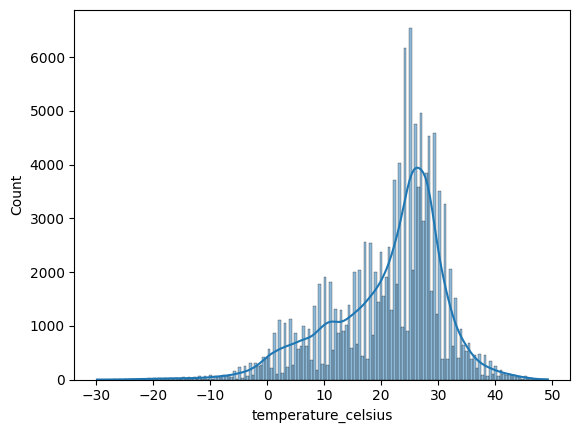

In [12]:
sns.histplot(df['temperature_celsius'],kde=True,palette='set2')

VIOLINPLOT

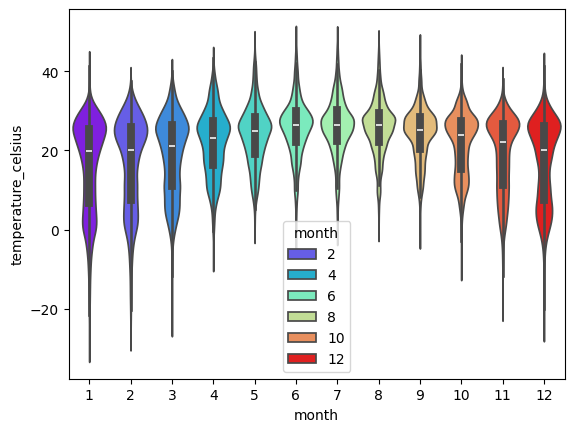

In [13]:
sns.violinplot(x='month', y='temperature_celsius',data=df,palette='rainbow',hue='month')
plt.show()

COUNTPLOT

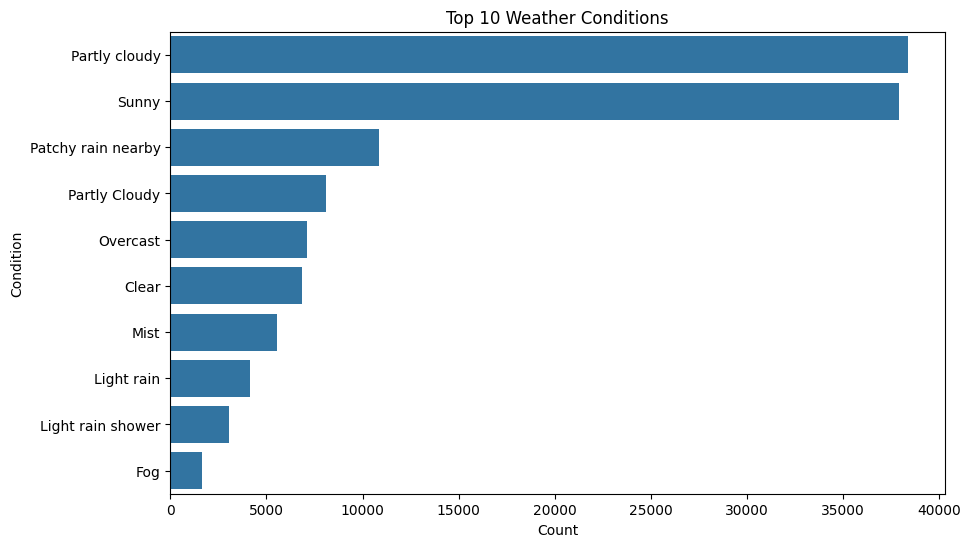

In [14]:
top_conditions = df['condition_text'].value_counts().head(10).index
plt.figure(figsize=(10,6))
sns.countplot(data=df[df['condition_text'].isin(top_conditions)],y='condition_text',order=top_conditions)
plt.title("Top 10 Weather Conditions")
plt.xlabel("Count")
plt.ylabel("Condition")
plt.show()

BOXPLOT

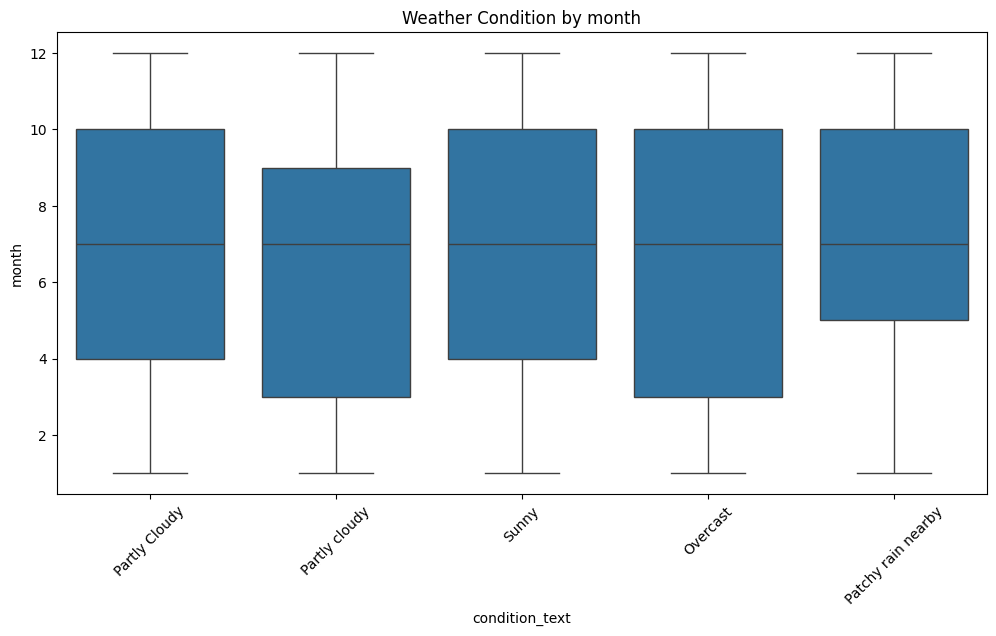

In [15]:
top_conditions = df['condition_text'].value_counts().head(5).index
plt.figure(figsize=(12,6))
sns.boxplot(x='condition_text',y='month',data=df[df['condition_text'].isin(top_conditions)])
plt.xticks(rotation=45)
plt.title("Weather Condition by month")
plt.show()

LINEPLOT

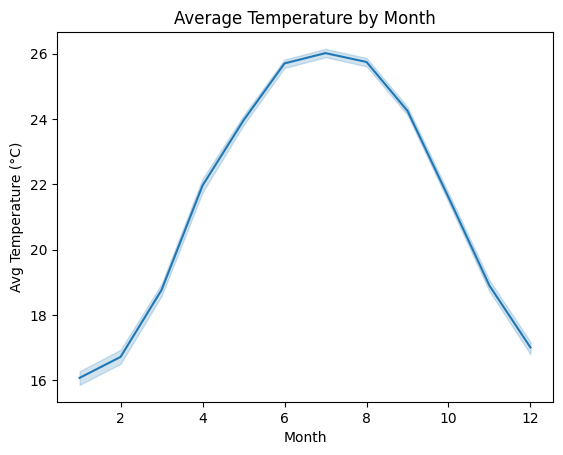

In [16]:
sns.lineplot(x='month', y='temperature_celsius', data=df, estimator='mean')
plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Avg Temperature (°C)")
plt.show()

In [17]:
df.to_csv("weather_data.csv", index=False)

MODEL TRAINING

In [18]:
# spliting the data 
X = df.drop(['temperature_celsius'], axis=1)
y = df['temperature_celsius']

In [19]:
X = pd.get_dummies(X, drop_first=True)

In [20]:
# test train split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# model training
model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train, y_train) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [22]:
#Predictions
y_pred = model.predict(X_test)
y_pred

array([11.877,  7.53 ,  6.702, ..., 14.715, 26.227, 29.268])

In [23]:
print('Training efficiency:',model.score(X_train,y_train))
print('Training efficiency:',model.score(X_test,y_test))

Training efficiency: 0.9945987203284804
Training efficiency: 0.961711141292251


In [24]:
#Evaluate model
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.961711141292251
MAE: 1.302811171827566
MSE: 3.611458567698847


In [25]:
import joblib

joblib.dump(model, "temperature_model.pkl")

['temperature_model.pkl']

In [26]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))